Accuracy: 85.98%
Confusion Matrix:
[[117  19]
 [ 18 110]]
R-squared: 0.4389
AUC-ROC: 0.9288


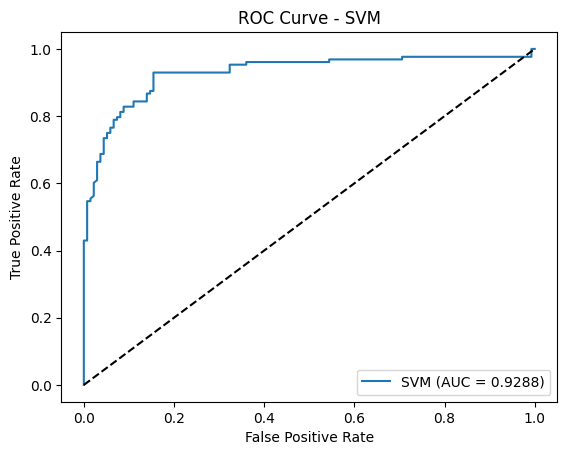

In [1]:
#SVM


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, roc_auc_score, roc_curve
from sklearn.svm import SVC

df = pd.read_csv('mass_case_description_train_set.csv')

y = df['pathology'].apply(lambda x: 1 if x == 'MALIGNANT' else 0)
df['mass shape'] = df['mass shape'].fillna('UNKNOWN')
df['mass margins'] = df['mass margins'].fillna('UNKNOWN')

features = ['breast_density', 'left or right breast', 'image view', 
            'mass shape', 'mass margins', 'assessment', 'subtlety']
X = pd.get_dummies(df[features], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(probability=True, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.show()

Accuracy: 86.74%
Confusion Matrix:
[[121  15]
 [ 20 108]]
R-squared: 0.4692
AUC-ROC: 0.9455


C:\Users\Parat\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [22:09:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


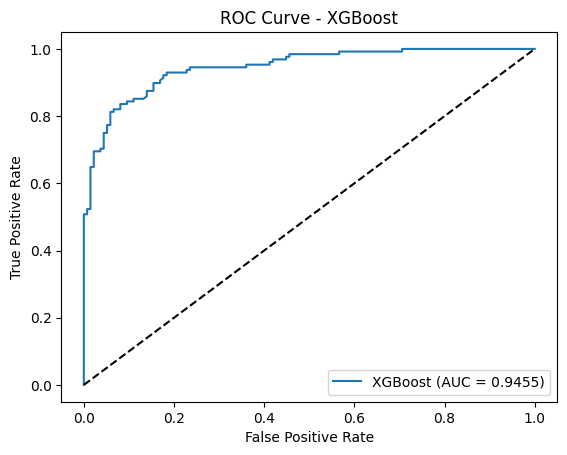

In [2]:
#XGBoost


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, roc_auc_score, roc_curve
from xgboost import XGBClassifier

df = pd.read_csv('mass_case_description_train_set.csv')

y = df['pathology'].apply(lambda x: 1 if x == 'MALIGNANT' else 0)
df['mass shape'] = df['mass shape'].fillna('UNKNOWN')
df['mass margins'] = df['mass margins'].fillna('UNKNOWN')

features = ['breast_density', 'left or right breast', 'image view', 
            'mass shape', 'mass margins', 'assessment', 'subtlety']
X = pd.get_dummies(df[features], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.show()

Accuracy: 90.15%
Confusion Matrix:
[[127   9]
 [ 17 111]]
R-squared: 0.6057
AUC-ROC: 0.9525


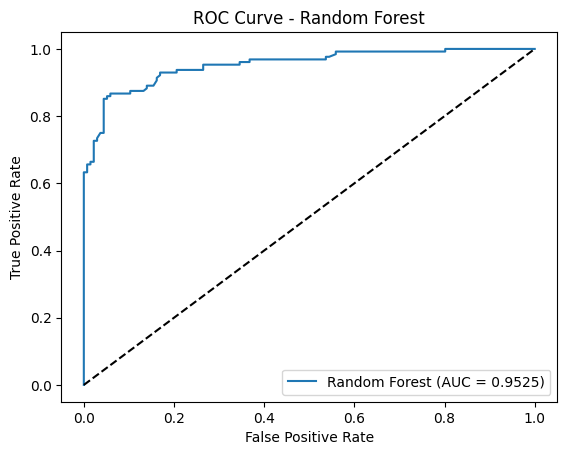

In [3]:
#Random Forest


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('mass_case_description_train_set.csv')

y = df['pathology'].apply(lambda x: 1 if x == 'MALIGNANT' else 0)
df['mass shape'] = df['mass shape'].fillna('UNKNOWN')
df['mass margins'] = df['mass margins'].fillna('UNKNOWN')

features = ['breast_density', 'left or right breast', 'image view', 
            'mass shape', 'mass margins', 'assessment', 'subtlety']
X = pd.get_dummies(df[features], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()

Accuracy: 86.36%
Confusion Matrix:
[[122  14]
 [ 22 106]]
R-squared: 0.4540
AUC-ROC: 0.8992


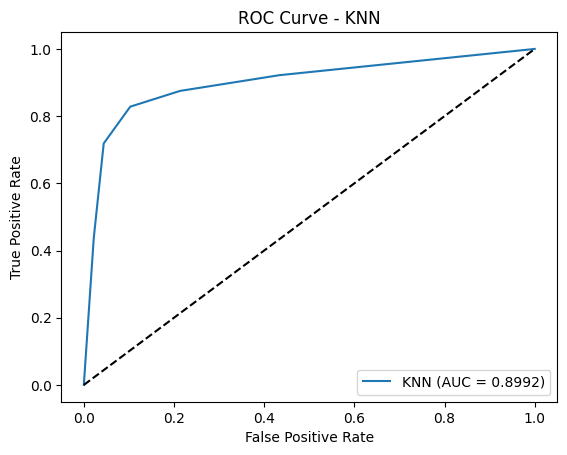

In [4]:
#KNN


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv('mass_case_description_train_set.csv')

y = df['pathology'].apply(lambda x: 1 if x == 'MALIGNANT' else 0)
df['mass shape'] = df['mass shape'].fillna('UNKNOWN')
df['mass margins'] = df['mass margins'].fillna('UNKNOWN')

features = ['breast_density', 'left or right breast', 'image view', 
            'mass shape', 'mass margins', 'assessment', 'subtlety']
X = pd.get_dummies(df[features], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = KNeighborsClassifier()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend(loc='lower right')
plt.show()

Accuracy: 85.98%
Confusion Matrix:
[[116  20]
 [ 17 111]]
R-squared: 0.4389
AUC-ROC: 0.9289


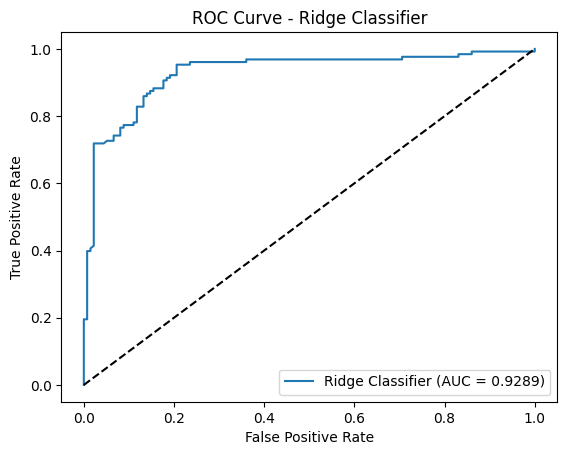

In [5]:
#Ridge Linear


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, roc_auc_score, roc_curve
from sklearn.linear_model import RidgeClassifier

df = pd.read_csv('mass_case_description_train_set.csv')

y = df['pathology'].apply(lambda x: 1 if x == 'MALIGNANT' else 0)
df['mass shape'] = df['mass shape'].fillna('UNKNOWN')
df['mass margins'] = df['mass margins'].fillna('UNKNOWN')

features = ['breast_density', 'left or right breast', 'image view', 
            'mass shape', 'mass margins', 'assessment', 'subtlety']
X = pd.get_dummies(df[features], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RidgeClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.decision_function(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Ridge Classifier (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Ridge Classifier')
plt.legend(loc='lower right')
plt.show()

Accuracy: 90.15%
Confusion Matrix:
[[128   8]
 [ 18 110]]
R-squared: 0.6057
AUC-ROC: 0.9424


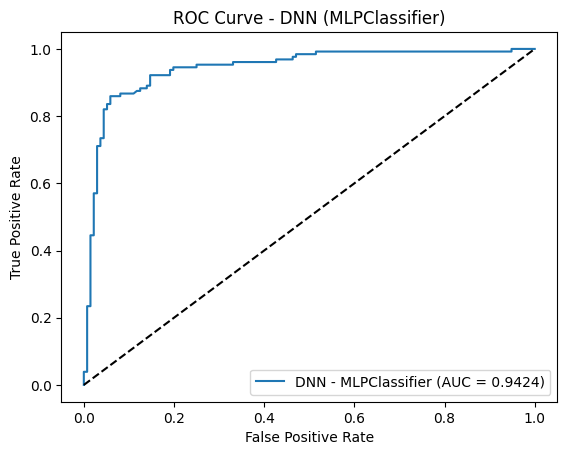

In [6]:
#Deep Neural Network - Multi Layer Perceptron


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, roc_auc_score, roc_curve
from sklearn.neural_network import MLPClassifier

# Load Data
df = pd.read_csv('mass_case_description_train_set.csv')

# Preprocessing
y = df['pathology'].apply(lambda x: 1 if x == 'MALIGNANT' else 0)
df['mass shape'] = df['mass shape'].fillna('UNKNOWN')
df['mass margins'] = df['mass margins'].fillna('UNKNOWN')

features = ['breast_density', 'left or right breast', 'image view', 
            'mass shape', 'mass margins', 'assessment', 'subtlety']
X = pd.get_dummies(df[features], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model 
# (Increased max_iter from 1000 to 2000 to ensure convergence on the more complex dummy variables)
model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Output Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'DNN - MLPClassifier (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DNN (MLPClassifier)')
plt.legend(loc='lower right')
plt.show()